<a href="https://colab.research.google.com/github/DeepthiManthapuram/Celebal_Excellence_Internship/blob/main/week6_Deepthi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project: Image Denoising using Autoencoder on MNIST**

# Import Required Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Load the MNIST Dataset

In [22]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


# Display Sample Images

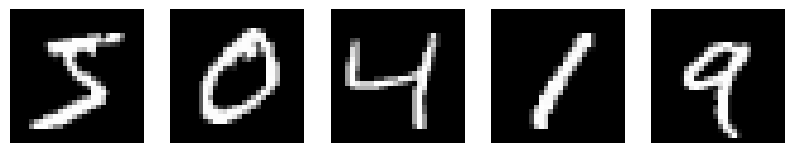

In [23]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.axis("off")

plt.show()

# Normalize Pixel Values

Pixel values range from 0 to 255. Dividing by 255 scales them to 0–1, which helps the neural network train more effectively.

In [24]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape Images

In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


# Add Gaussian Noise

In [26]:
noise_factor = 0.4

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape)

# Clip Pixel Values

In [27]:
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# Compare Original and Noisy Images

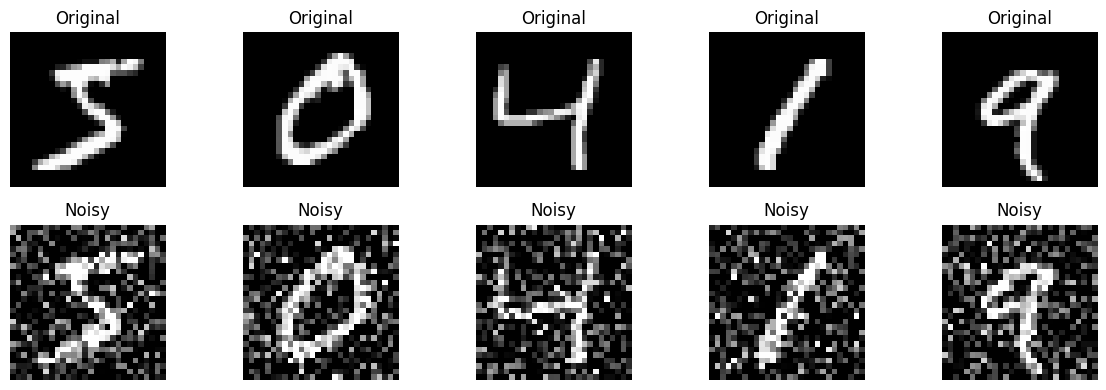

In [28]:
plt.figure(figsize=(12,4))

for i in range(5):
    # Original Image
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(2,5,i+6)
    plt.imshow(X_train_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Define the Input Layer

In [29]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Input image size
input_img = Input(shape=(28, 28, 1))

# Build the Encoder

In [30]:
# Encoder

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Build the Decoder

In [31]:
# Decoder

x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3),
                 activation='sigmoid',
                 padding='same')(x)

# Create the Autoencoder Model

In [32]:
autoencoder = Model(inputs=input_img,
                    outputs=decoded)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

In [33]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Train the Autoencoder

In [34]:
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.1676 - val_loss: 0.1086
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1056 - val_loss: 0.1012
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1006 - val_loss: 0.0982
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0977 - val_loss: 0.0956
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0957 - val_loss: 0.0940
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0944 - val_loss: 0.0931
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0934 - val_loss: 0.0921
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0927 - val_loss: 0.0915
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0921 - val_loss: 0.0909
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0916 - val_loss: 0.0904


# Plot the Training and Validation Loss

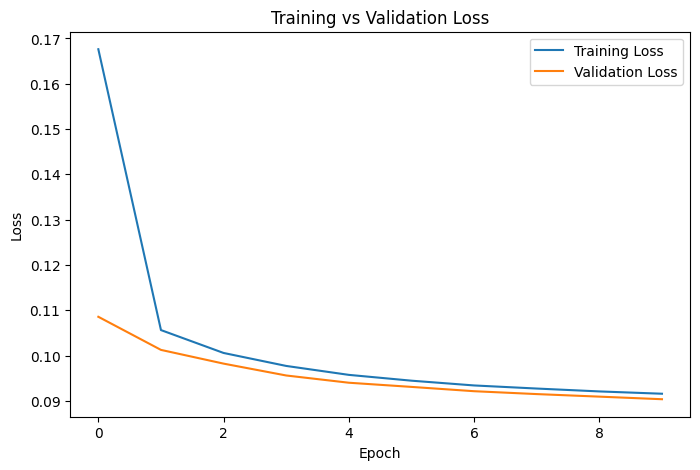

In [35]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Predict (Denoise) the Test Images

In [36]:
# Generate denoised images

decoded_imgs = autoencoder.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


# Display Original, Noisy, and Reconstructed Images

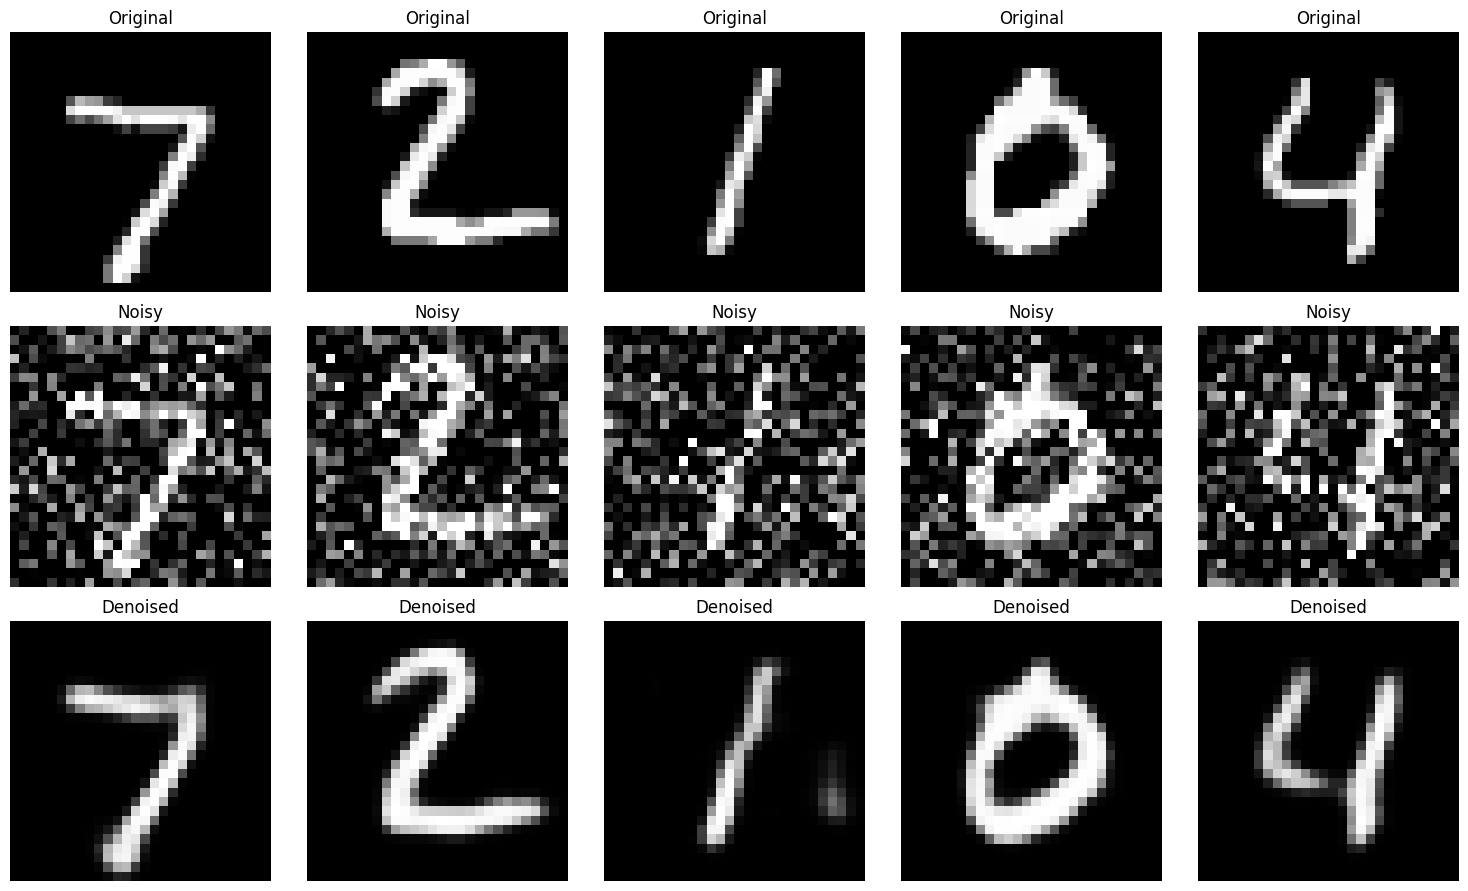

In [37]:
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Original Image
    plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed Image
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Save the Trained Model

In [38]:
# Save the trained autoencoder

autoencoder.save("mnist_denoising_autoencoder.keras")

print("Model saved successfully!")

Model saved successfully!
